In [1]:
!pip install --upgrade keras-hub keras-nlp keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 88.2 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2
  Attempting uninstall: keras-hub
    Found existing installation: keras-hub 0.26.0
    Uninstalling keras-hub-0.26.0:
      Successfully uninstalled keras-hub-0.26.0
  Attempting uninstall: keras-nlp
    Found existing installation: keras-nlp 0.26.0
    Uninstalling keras-nlp-0.26.0:
      Successfully uninstalled keras-nlp-0.26.0


In [2]:
!nvidia-smi

Fri Apr 10 20:20:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import keras as kr
import seaborn as sb
import sklearn
import tensorflow as tf
import keras_hub as kr_h
from keras.preprocessing.sequence import pad_sequences
from keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

sklearn.set_config(transform_output="pandas")

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
%cd /content/drive/My Drive/Bible_nn/

/content/drive/My Drive/Bible_nn


In [6]:
in_file=open("bible_ready.txt","r", errors='ignore',encoding='utf8')
text=in_file.read()
in_file.close()
T=text.split("\n")
ord_len=len(T)
print(T)

['na', 'początku', 'bóg', 'stworzył', 'niebo', 'i', 'ziemię', 'a', 'ziemia', 'była', 'bezkształtna', 'i', 'pusta', 'i', 'ciemność', 'była', 'nad', 'głębią', 'a', 'duch', 'boży', 'unosił', 'się', 'nad', 'wodami', 'i', 'bóg', 'powiedział', 'niech', 'stanie', 'się', 'światłość', 'i', 'stała', 'się', 'światłość', 'bóg', 'widział', 'że', 'światłość', 'była', 'dobra', 'i', 'oddzielił', 'bóg', 'światłość', 'od', 'ciemności', 'i', 'nazwał', 'bóg', 'światłość', 'dniem', 'a', 'ciemność', 'nazwał', 'nocą', 'i', 'nastał', 'wieczór', 'i', 'poranek', 'dzień', 'pierwszy', 'potem', 'bóg', 'powiedział', 'niech', 'stanie', 'się', 'firmament', 'pośrodku', 'wód', 'i', 'niech', 'oddzieli', 'wody', 'od', 'wód', 'i', 'uczynił', 'bóg', 'firmament', 'i', 'oddzielił', 'wody', 'które', 'są', 'pod', 'firmamentem', 'od', 'wód', 'które', 'są', 'nad', 'firmamentem', 'i', 'tak', 'się', 'stało', 'i', 'bóg', 'nazwał', 'firmament', 'niebem', 'i', 'nastał', 'wieczór', 'i', 'poranek', 'dzień', 'drugi', 'potem', 'bóg', 'po

In [7]:
WS=np.array(sorted(set(T)))
ws_len=len(WS)+1
word_to_id = {word: i+1 for i, word in enumerate(WS)}
id_to_word = {i+1: word for i, word in enumerate(WS)}
print(id_to_word)

{1: np.str_('a'), 2: np.str_('aaron'), 3: np.str_('aarona'), 4: np.str_('aaronem'), 5: np.str_('aaronie'), 6: np.str_('aaronitami'), 7: np.str_('aaronowi'), 8: np.str_('abaddon'), 9: np.str_('abagcie'), 10: np.str_('abana'), 11: np.str_('abarim'), 12: np.str_('abba'), 13: np.str_('abda'), 14: np.str_('abdeel'), 15: np.str_('abdeela'), 16: np.str_('abdi'), 17: np.str_('abdiasz'), 18: np.str_('abdiasza'), 19: np.str_('abdiego'), 20: np.str_('abdiela'), 21: np.str_('abdon'), 22: np.str_('abdonowi'), 23: np.str_('abdy'), 24: np.str_('abed-nego'), 25: np.str_('abel'), 26: np.str_('abel-bet-maaka'), 27: np.str_('abel-mechola'), 28: np.str_('abel-szittim'), 29: np.str_('abelmaim'), 30: np.str_('abelu'), 31: np.str_('abi'), 32: np.str_('abi-albon'), 33: np.str_('abia'), 34: np.str_('abiasaf'), 35: np.str_('abiasz'), 36: np.str_('abiasza'), 37: np.str_('abiaszem'), 38: np.str_('abiatar'), 39: np.str_('abiatara'), 40: np.str_('abiatarem'), 41: np.str_('abiatarowi'), 42: np.str_('abib'), 43: np.s

In [8]:
freq={word:0 for word in WS}
for t in T:
    freq[t]+=1
asc = {k: 100*v/len(T) for k, v in sorted(freq.items(), key=lambda item: item[1],reverse=True)}
freq

{np.str_('a'): 10363,
 np.str_('aaron'): 115,
 np.str_('aarona'): 193,
 np.str_('aaronem'): 9,
 np.str_('aaronie'): 2,
 np.str_('aaronitami'): 1,
 np.str_('aaronowi'): 32,
 np.str_('abaddon'): 1,
 np.str_('abagcie'): 1,
 np.str_('abana'): 1,
 np.str_('abarim'): 4,
 np.str_('abba'): 3,
 np.str_('abda'): 1,
 np.str_('abdeel'): 2,
 np.str_('abdeela'): 1,
 np.str_('abdi'): 1,
 np.str_('abdiasz'): 5,
 np.str_('abdiasza'): 3,
 np.str_('abdiego'): 2,
 np.str_('abdiela'): 1,
 np.str_('abdon'): 7,
 np.str_('abdonowi'): 1,
 np.str_('abdy'): 1,
 np.str_('abed-nego'): 15,
 np.str_('abel'): 6,
 np.str_('abel-bet-maaka'): 2,
 np.str_('abel-mechola'): 3,
 np.str_('abel-szittim'): 1,
 np.str_('abelmaim'): 1,
 np.str_('abelu'): 1,
 np.str_('abi'): 1,
 np.str_('abi-albon'): 1,
 np.str_('abia'): 1,
 np.str_('abiasaf'): 1,
 np.str_('abiasz'): 14,
 np.str_('abiasza'): 8,
 np.str_('abiaszem'): 2,
 np.str_('abiatar'): 9,
 np.str_('abiatara'): 19,
 np.str_('abiatarem'): 1,
 np.str_('abiatarowi'): 2,
 np.str_(

In [9]:
wei=[0]+[1]*len(T)

In [10]:
ordered_ids = [word_to_id[w] for w in T]
ordered_ids

[10918,
 17289,
 1925,
 26267,
 12225,
 6640,
 36706,
 1,
 36699,
 1905,
 1223,
 6640,
 22052,
 6640,
 2803,
 1905,
 11051,
 6360,
 1,
 4526,
 1616,
 29219,
 24553,
 11051,
 31078,
 6640,
 1925,
 19172,
 12227,
 25771,
 24553,
 38477,
 6640,
 25916,
 24553,
 38477,
 1925,
 30633,
 38645,
 38477,
 1905,
 3758,
 6640,
 14048,
 1925,
 38477,
 13842,
 2800,
 6640,
 12044,
 1925,
 38477,
 3747,
 1,
 2803,
 12044,
 12927,
 6640,
 11819,
 30688,
 6640,
 18425,
 4787,
 16668,
 18950,
 1925,
 19172,
 12227,
 25771,
 24553,
 5393,
 19722,
 33907,
 6640,
 12227,
 14044,
 31084,
 13842,
 33907,
 6640,
 28558,
 1925,
 5393,
 6640,
 14048,
 31084,
 8792,
 27121,
 17302,
 5394,
 13842,
 33907,
 8792,
 27121,
 11051,
 5394,
 6640,
 27446,
 24553,
 25924,
 6640,
 1925,
 12044,
 5393,
 12203,
 6640,
 11819,
 30688,
 6640,
 18425,
 4787,
 4452,
 18950,
 1925,
 19172,
 12227,
 24553,
 35914,
 30247,
 7176,
 10080,
 31084,
 8792,
 27121,
 17302,
 12203,
 6640,
 12227,
 24553,
 28838,
 26306,
 19203,
 6640,

In [11]:
SEQ_CHUNK = 10
embed_dim = 128
head_dim=4
mlp_dim=embed_dim*4
sequences = []
for i in range(0, len(ordered_ids), 1):
    chunk = ordered_ids[i : i + SEQ_CHUNK+1]
    if len(chunk) > 1:
        sequences.append(chunk)
X_list = [seq[:-1] for seq in sequences]
y_list = [seq[1:]  for seq in sequences]
X2 = pad_sequences(X_list, padding='post', value=0)
y2 = pad_sequences(y_list, padding='post', value=0)
len(X_list)

583408

In [12]:
class TrainableDistanceMultiHeadAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        
        if embed_dim % num_heads != 0:
            raise ValueError("embed_dim musi być podzielne przez num_heads")
        self.head_dim = embed_dim // num_heads
        
        self.wq = layers.Dense(embed_dim)
        self.wk = layers.Dense(embed_dim)
        self.wv = layers.Dense(embed_dim)
        self.wo = layers.Dense(embed_dim)
        self.w_raw = self.add_weight(
            name="distance_decay_weight",
            shape=(1,),
            initializer="zeros", 
            trainable=True
        )

    def call(self, q, k, v, use_causal_mask=True):
        batch_size = tf.shape(q)[0]
        seq_len = tf.shape(q)[1]
        
        q = self.wq(q)
        k = self.wk(k)
        v = self.wv(v)
        
        q = tf.transpose(tf.reshape(q, (batch_size, seq_len, self.num_heads, self.head_dim)), (0, 2, 1, 3))
        k = tf.transpose(tf.reshape(k, (batch_size, seq_len, self.num_heads, self.head_dim)), (0, 2, 1, 3))
        v = tf.transpose(tf.reshape(v, (batch_size, seq_len, self.num_heads, self.head_dim)), (0, 2, 1, 3))
        
        scores = tf.matmul(q, k, transpose_b=True) / tf.math.sqrt(tf.cast(self.head_dim, tf.float32))
        
        i = tf.range(seq_len)[:, tf.newaxis] 
        j = tf.range(seq_len)
        
        if use_causal_mask:
            causal_mask = tf.cast(i >= j, tf.float32)
            scores = scores + (1.0 - causal_mask) * -1e9
            
        weights = tf.nn.softmax(scores, axis=-1)
        W = tf.math.sigmoid(self.w_raw)
        n = tf.cast(i - j, tf.float32)
        n_safe = tf.maximum(n, 1.0)
        multiplier = tf.where(n > 0.0, tf.math.pow(W, n_safe - 1.0), 1.0)
        
        weights = weights * multiplier
        
        weights = weights / tf.reduce_sum(weights, axis=-1, keepdims=True)
        
        
        out = tf.matmul(weights, v)
        
        out = tf.transpose(out, (0, 2, 1, 3))
        out = tf.reshape(out, (batch_size, seq_len, self.embed_dim))
        
        return self.wo(out)

In [13]:
class full_attention_block(layers.Layer):
    def __init__(self, embed_dim, head_dim, mlp_dim, **kwargs):
        super(full_attention_block, self).__init__(**kwargs)

        self.embed_dim = embed_dim
        self.head_dim = head_dim
        self.mlp_dim = mlp_dim

        self.norm_layer_at = layers.LayerNormalization()
        # Zastąpienie wbudowanego Kerasowego MHA naszą wersją
        self.attention_layer = TrainableDistanceMultiHeadAttention(embed_dim=embed_dim, num_heads=head_dim)
        self.norm_layer_mlp = layers.LayerNormalization()
        self.mlp_dense_layer_up = layers.Dense(mlp_dim, activation="softplus")
        self.mlp_dense_layer_down = layers.Dense(embed_dim, activation="linear")

    def call(self, block_in):
        block_in_norm = self.norm_layer_at(block_in)
        # Przekazujemy ten sam wektor jako Q, K i V (Self-Attention)
        at = self.attention_layer(block_in_norm, block_in_norm, block_in_norm, use_causal_mask=True)
        at_sum = block_in + at
        at_norm = self.norm_layer_mlp(at_sum)
        mlp_up = self.mlp_dense_layer_up(at_norm)
        mlp_down = self.mlp_dense_layer_down(mlp_up)
        return at + mlp_down
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "head_dim": self.head_dim,
            "mlp_dim": self.mlp_dim,
        })
        return config

In [14]:
class at_connection(layers.Layer):
    def __init__(self, at_dim, mult=4, **kwargs):
        super(at_connection, self).__init__(**kwargs)

        self.at_dim = at_dim
        self.mult = mult
        bias_init_values = np.arange(self.at_dim, dtype=np.float32)
        bias_initializer = tf.keras.initializers.Constant(bias_init_values)

        self.stack_layer = layers.Lambda(lambda x : tf.stack(x,axis=-1))
        self.dense_layer_up = layers.Dense(at_dim*mult, activation="softplus")
        self.dense_layer_down = layers.Dense(at_dim, activation="softmax", kernel_initializer="zeros", bias_initializer=bias_initializer)
        #self.permute_down = layers.Permute((3, 2, 1))
        self.multiply_layer = layers.Multiply()
        self.sum_layer = layers.Lambda(lambda x: tf.reduce_sum(x, axis=-1))

    def call(self, at_changes):
        at_block=self.stack_layer(at_changes)
        up = self.dense_layer_up(at_block)
        down = self.dense_layer_down(up)
        #down_perm = self.permute_down(down)
        post_mult = self.multiply_layer([at_block,down])
        final = self.sum_layer(post_mult)
        return final
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "at_dim": self.at_dim,
            "mult": self.mult
        })
        return config

In [15]:
at_block_number=10
def zero(x):
    return 0
input_layer = layers.Input(shape=(None,), dtype='int32')
embedding_layer = kr_h.layers.ReversibleEmbedding(input_dim=ws_len, output_dim=embed_dim)
at_block_list=[]
conn_list=[]
for i in range(at_block_number):
    at_block_list.append(full_attention_block(embed_dim,head_dim,mlp_dim))
for i in range(at_block_number):
    if i<1:
        conn_list.append(zero)
    else:
        conn_list.append(at_connection(i+1,4))
final_norm_layer=layers.LayerNormalization()
output_layer = layers.Activation('softmax')

In [16]:
input=input_layer
e_v=embedding_layer(input)

atb_v=e_v
conn=0
at_changes=[]
for i in range(at_block_number):
    at_ch=at_block_list[i](atb_v)
    at_changes.append(at_ch)
    conn=conn_list[i](at_changes)
    atb_v=e_v+conn
f_n=final_norm_layer(atb_v)
re_v=embedding_layer(f_n, reverse=True)
output=output_layer(re_v)

In [17]:
model=Model(inputs=input_layer,outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reversible_embeddi… │ (None, None,      │  4,977,024 │ input_layer[0][0… │
│ (ReversibleEmbeddi… │ 38883)            │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None, 128) │          0 │ reversible_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ full_attention_blo… │ (None, None, 128) │    198,273 │ reversible_embed… │
│ (full_attention_bl… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ full_attention_blo… │ (None, None, 128) │    198,273 │ add[0][0]         │
│ (full_attention_bl… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ at_connection       │ (None, None, 128) │         42 │ full_attention_b… │
│ (at_connection)     │                   │            │ full_attention_b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, None, 128) │          0 │ reversible_embed… │
│                     │                   │            │ at_connection[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ full_attention_blo… │ (None, None, 128) │    198,273 │ add_1[0][0]       │
│ (full_attention_bl… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ at_connection_1     │ (None, None, 128) │         87 │ full_attention_b… │
│ (at_connection)     │                   │            │ full_attention_b… │
│                     │                   │            │ full_attention_b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, None, 128) │          0 │ reversible_embed… │
│                     │                   │            │ at_connection_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ full_attention_blo… │ (None, None, 128) │    198,273 │ add_2[0][0]       │
│ (full_attention_bl… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ at_connection_2     │ (None, None, 128) │        148 │ full_attention_b… │
│ (at_connection)     │                   │            │ full_attention_b… │
│                     │                   │            │ full_attention_b… │
│                     │                   │            │ full_attention_b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, None, 128) │          0 │ reversible_embed… │
│                     │                   │            │ at_connection_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ full_attention_blo… │ (None, None, 128) │    198,273 │ add_3[0][0]       │
│ (full_attention_bl… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ at_connection_3     │ (None, None, 128) │        225 │ full_attention_b… │
│ (at_connection)     │                   │            │ full_attention_b… │
│                     │                   │            │ full_attention_b… │
│                     │                   │            │ full_attention_b… │
│                     │                   │            │ full_attention_b

 Total params: 6,963,352 (26.56 MB)

 Trainable params: 6,963,352 (26.56 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
kr.utils.plot_model(model, show_shapes=True)

In [14]:
model = kr.models.load_model(
    "attention_wl45.keras",
    custom_objects={"full_attention_block": full_attention_block,
                    "TrainableDistanceMultiHeadAttention": TrainableDistanceMultiHeadAttention
                    }
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'full_attention_block_7', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'full_attention_block_8', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'full_attention_bloc

In [19]:
Adam = kr.optimizers.Adam(learning_rate=0.001)


In [20]:
model.compile(optimizer=Adam,loss="sparse_categorical_crossentropy",metrics=['accuracy'])

In [21]:
history = model.fit(X2, y2,epochs=3,batch_size=128)

Epoch 1/3
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 499s 97ms/step - accuracy: 0.2326 - loss: 4.9359
Epoch 2/3
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 425s 93ms/step - accuracy: 0.4423 - loss: 2.8883
Epoch 3/3
4558/4558 ━━━━━━━━━━━━━━━━━━━━ 424s 93ms/step - accuracy: 0.5570 - loss: 2.1704


In [ ]:
import os

# 1. Próbujemy cicho zmienić katalog roboczy przez moduł 'os' (często radzi sobie lepiej z błędami FUSE niż %cd)
try:
    os.chdir('/content/')
    print("Katalog roboczy zmieniony na /content/")
except Exception as e:
    print(f"Nie udało się zmienić katalogu, ale kontynuujemy używając ścieżki absolutnej: {e}")

# 2. Zapisujemy model, twardo wskazując ścieżkę poza zepsutym dyskiem Google
sciezka_zapisu = '/content/attention_distance10.keras'
model.save(sciezka_zapisu)
print(f"Sukces! Model bezpiecznie zapisany w: {sciezka_zapisu}")

# 3. Wywołujemy pobieranie pliku przez przeglądarkę
from google.colab import files
files.download(sciezka_zapisu)

Katalog roboczy zmieniony na /content/
Sukces! Model bezpiecznie zapisany w: /content/attention_distance10.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download(sciezka_zapisu)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
model.save('monster_3.keras')

In [ ]:
print(len(X[0]))

4


In [18]:
def evluate_length(model,length):
    #SEQ_CHUNK = length
    sequences = []
    for i in range(0, len(ordered_ids), 1):
        chunk = ordered_ids[i : i + length+1]
        if len(chunk) > 1:
            sequences.append(chunk)
    X_list = [seq[:-1] for seq in sequences]
    y_list = [seq[1:]  for seq in sequences]
    X = pad_sequences(X_list, padding='post', value=0)
    y = pad_sequences(y_list, padding='post', value=0)
    res=model.evaluate(X,y)
    print(f"{length}:\t{res[1]}")
    return res[1]
def plot_seq_to(n):
    acc=np.array([(i,evluate_length(model,i)) for i in range (1,n+1)])
    #acc=np.array(
    #    [(1,0.1849),(2,0.2733),(3,0.3468),(4,0.4072),(5,0.4569),(6,0.4981),(7,0.5322),(8,0.5600),(9,0.5823),(10,0.5985),(11,0.6040),(12,0.6024),(13,0.5965),(14,0.5878),(15,0.5774),(16,0.5660),(17,0.5542),(18,0.5422),(19,0.5303),(20,0.5185)]
    #)
    df_acc=pd.DataFrame(acc,columns=["seq_len","accuracy"])
    print(df_acc)
    sb.lineplot(data=df_acc, x="seq_len",y="accuracy")
    

18232/18232 ━━━━━━━━━━━━━━━━━━━━ 88s 5ms/step - accuracy: 0.1904 - loss: 4.6231
1:	0.190415620803833
18232/18232 ━━━━━━━━━━━━━━━━━━━━ 101s 5ms/step - accuracy: 0.3455 - loss: 3.4224
2:	0.34549492597579956
18232/18232 ━━━━━━━━━━━━━━━━━━━━ 99s 5ms/step - accuracy: 0.4904 - loss: 2.5679
3:	0.4904134273529053
18232/18232 ━━━━━━━━━━━━━━━━━━━━ 98s 5ms/step - accuracy: 0.5985 - loss: 1.9991
4:	0.5984722375869751
18232/18232 ━━━━━━━━━━━━━━━━━━━━ 97s 5ms/step - accuracy: 0.6731 - loss: 1.6217
5:	0.6730720400810242
18232/18232 ━━━━━━━━━━━━━━━━━━━━ 98s 5ms/step - accuracy: 0.7254 - loss: 1.3609
6:	0.7253658175468445
18232/18232 ━━━━━━━━━━━━━━━━━━━━ 100s 5ms/step - accuracy: 0.7635 - loss: 1.1716
7:	0.7634871006011963
18232/18232 ━━━━━━━━━━━━━━━━━━━━ 103s 6ms/step - accuracy: 0.7924 - loss: 1.0285
8:	0.7923905849456787
18232/18232 ━━━━━━━━━━━━━━━━━━━━ 107s 6ms/step - accuracy: 0.8150 - loss: 0.9168
9:	0.8150142431259155
18232/18232 ━━━━━━━━━━━━━━━━━━━━ 110s 6ms/step - accuracy: 0.8332 - loss: 0.82

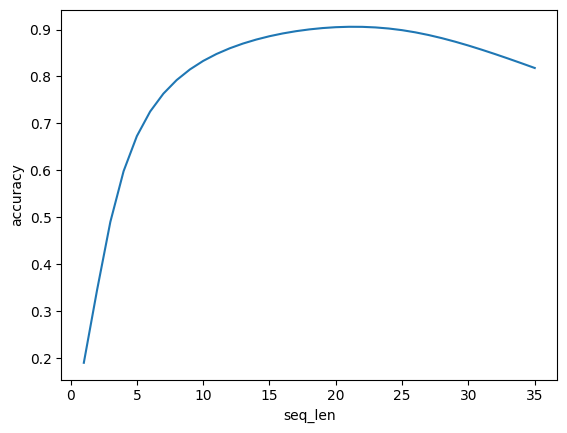

In [19]:
plot_seq_to(35)

In [ ]:
from google.colab import runtime
runtime.unassign()

In [50]:
model.evaluate(X2,y2)

18232/18232 ━━━━━━━━━━━━━━━━━━━━ 119s 6ms/step - accuracy: 0.8369 - loss: 0.8059


[0.8058825731277466, 0.8368808031082153]

In [ ]:
"""
attention_b16 | accuracy: 0.8369 - loss: 0.8059
attention_b13 | accuracy: 0.7816 - loss: 1.0481
attention_b10 | accuracy: 0.7659 - loss: 1.1186

"""

In [ ]:
print("--- Wyuczone wagi odległości W ---")

# Iterujemy po wszystkich warstwach głównego modelu
for layer in model.layers:
    
    # Sprawdzamy, czy dana warstwa to nasz autorski `full_attention_block`
    # Upewniamy się, że posiada atrybut `attention_layer`, a w nim `w_raw`
    if hasattr(layer, 'attention_layer') and hasattr(layer.attention_layer, 'w_raw'):
        
        # 1. Pobieramy surową wartość (w_raw) jako zwykłą liczbę
        w_raw_value = layer.attention_layer.w_raw.numpy()[0]
        
        # 2. Ręcznie obliczamy wartość po aktywacji sigmoid: 1 / (1 + e^-x)
        # To da nam ostateczny ułamek W z przedziału (0, 1)
        w_final = 1.0 / (1.0 + np.exp(-w_raw_value))
        
        print(f"Blok atencji: {layer.name}")
        print(f"  -> Surowa waga (w_raw): {w_raw_value:.4f}")
        print(f"  -> Ostateczny mnożnik (W): {w_final:.4f}")
        print("-" * 35)

--- Wyuczone wagi odległości W ---
Blok atencji: full_attention_block_7
  -> Surowa waga (w_raw): 0.7267
  -> Ostateczny mnożnik (W): 0.6741
-----------------------------------
Blok atencji: full_attention_block_8
  -> Surowa waga (w_raw): 0.2643
  -> Ostateczny mnożnik (W): 0.5657
-----------------------------------
Blok atencji: full_attention_block_9
  -> Surowa waga (w_raw): 0.7589
  -> Ostateczny mnożnik (W): 0.6811
-----------------------------------
Blok atencji: full_attention_block_10
  -> Surowa waga (w_raw): -0.5758
  -> Ostateczny mnożnik (W): 0.3599
-----------------------------------
Blok atencji: full_attention_block_11
  -> Surowa waga (w_raw): 0.7065
  -> Ostateczny mnożnik (W): 0.6696
-----------------------------------
Blok atencji: full_attention_block_12
  -> Surowa waga (w_raw): 0.2866
  -> Ostateczny mnożnik (W): 0.5712
-----------------------------------
Blok atencji: full_attention_block_13
  -> Surowa waga (w_raw): 2.1762
  -> Ostateczny mnożnik (W): 0.8981
--

In [ ]:
def temp_pred(last_word_proba,temp):
    preds=last_word_proba.copy()
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds + 1e-7) / temp
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)

def next_word(ws_test,mode,temp=0.5):
    seq=np.array([ws_test])
    prediction=model.predict(seq)
    last_word_proba=prediction[0, -1, :]
    next_word_id=""
    if mode == "soft":
        next_word_id = np.random.choice(len(last_word_proba), p=last_word_proba)
    elif mode=="temp":
        next_word_id = temp_pred(last_word_proba,temp)
    else:
        if mode == "many":
            best_word_dict={id_to_word[i+1]:last_word_proba[i+1] for i in range(len(last_word_proba)-1)}
            best_word_list=[(k, best_word_dict[k]) for k in sorted(best_word_dict, key=best_word_dict.get, reverse=True)]
            print(best_word_list[:10])
        next_word_id = np.argmax(last_word_proba)
    #print(id_to_word[next_word_id],last_word_proba[next_word_id])
    return next_word_id
def generate_me_bible(S,n,mode="soft",temp=0.5):
    Tab=np.array(S.split(" "))
    ws_test=[word_to_id[w] for w in Tab]
    for i in range(n):
        next=next_word(ws_test,mode,temp)
        ws_test.append(next)
    result=""
    for w in ws_test:
        result+=id_to_word[w]+" "
    return result

In [ ]:
G=generate_me_bible("pan jezus powiedział do swoich",40,"many",0)
print(G)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
[(np.str_('uczniów'), np.float32(0.7586771)), (np.str_('sług'), np.float32(0.19691192)), (np.str_('braci'), np.float32(0.040005848)), (np.str_('i'), np.float32(0.0030370404)), (np.str_('synów'), np.float32(0.00053738395)), (np.str_('czyż'), np.float32(0.00041293286)), (np.str_('zięciów'), np.float32(0.00022468848)), (np.str_('siedemdziesięciu'), np.float32(0.00013288278)), (np.str_('służących'), np.float32(1.5140727e-05)), (np.str_('serajasza'), np.float32(6.727274e-06))]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
[(np.str_('zbierzcie'), np.float32(0.2953682)), (np.str_('wiecie'), np.float32(0.21183227)), (np.str_('przyjmijcie'), np.float32(0.17988397)), (np.str_('cóż'), np.float32(0.044131678)), (np.str_('jeśli'), np.float32(0.03254165)), (np.str_('żniwo'), np.float32(0.031317156)), (np.str_('nie'), np.float32(0.031275906)), (np.str_('a'), np.float32(0.027151065)), (np.str_('strzeżcie'), np.float32(0.02360307)), (np.str_('i'), np.float32(0.023106229))]